In [1]:
from rnd_spectra.bumps import Bumps
from rnd_spectra.ontheflydataset import OnTheFlyDataset, pointwise_G_normalization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
sns.set_theme(style="ticks",palette='tab10',rc={'axes.labelsize':14})
from torch.utils.data import DataLoader
from tld.configs import ModelConfig, TrainConfig, SpectralDataConfig, DenoiserConfig
from tld.diffusion import DiffusionGenerator
from tld.train import main
from dataclasses import asdict
from softmax_mean import SoftmaxMean

In [22]:
hparams = {
    'omega_domain': (0, 50.0),
    'num_bumps_range': (1,4), 
    'bump_widths_fraction_range': (0.1, 0.6), 
    'bump_centers_fraction_range': (0.0, 0.5)
}
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)

In [23]:
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
dataloader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=0)

0.9995436315785142
0.9991176220576664
0.9999412706672062
0.9987613198580872
0.997540141326397
0.9990590613766844
0.9995877096622316
0.9994473857424784
0.999848415886495


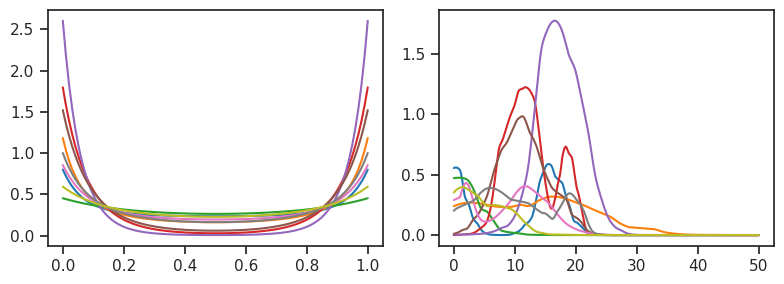

In [47]:
tau = dataloader.dataset.laplace.tau
omega = dataloader.dataset.laplace.omega
palette = ['C' + str(x) for x in range(250000)]
n_ex = 9
for C, G in dataloader:
    fig,axs = plt.subplots(1,2,figsize=(8,3))
    for j in range(n_ex):
        axs[0].plot(tau,G[j].cpu().detach().numpy().flatten(), color=palette[j])   
        # print(np.trapz(y=G[j].cpu().detach().numpy().flatten(),x=tau)*np.pi)
        axs[1].plot(omega,C[j].cpu().detach().numpy().flatten(), color=palette[j])
        print(np.trapz(y=C[j].cpu().detach().numpy().flatten()*(( 1 - np.exp(-omega) + 1e-20 ) / ( omega + 1e-20 )),x=omega))
    plt.tight_layout()
    plt.show()

In [5]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(omega_domain=(0,50),num_bumps_range=(1,4),bump_widths_fraction_range=(0.1, 0.45)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256),
    train_config=TrainConfig(compile=False, lr=3e-5, batch_size=50,n_epoch=200,use_wandb=True,save_model=True,model_name='sharper_peaks_12layers')
    )
model = main(model_cfg)

Creating training loader:
model prep


wandb: Currently logged in as: sagimeir (sagimeir-tel-aviv-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


The model has 11383564 parameters


100%|██████████| 400/400 [01:25<00:00,  4.70it/s]


...

100%|██████████| 400/400 [01:21<00:00,  4.88it/s]


epoch: 199 | train_loss: 0.01170431045582518


100%|██████████| 400/400 [01:22<00:00,  4.86it/s]

epoch: 200 | train_loss: 0.011781151184113697


train_loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,0.01178


In [2]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(omega_domain=(0,50),num_bumps_range=(1,4),bump_widths_fraction_range=(0.1, 0.45)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256),
    train_config=TrainConfig(
        compile=False, 
        lr=3e-5, 
        batch_size=50,
        n_epoch=720,
        use_wandb=True,
        save_model=True,
        model_name='sharper_peaks_12layers',
        from_scratch=False,
        run_id = 'ebqwn67s'
        )
    )
# model = main(model_cfg)

In [3]:
from tld.denoiser import Denoiser
model = Denoiser(**asdict(model_cfg.denoiser_config))
model.load_state_dict(torch.load('sharper_peaks_12layers',map_location=torch.device('cuda'))["model_ema"])

<All keys matched successfully>

In [4]:
hparams = asdict(model_cfg.data_config)
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


In [5]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list = [diffuser.generate(
        labels= G_test.to('cuda'),
        num_specs=9,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        constraint_guidance=0.1,
        tau = test_loader.dataset.laplace.tau,
        omega = test_loader.dataset.laplace.omega,
        # prior_knowledge=C_test.to('cuda'),
        # directed_positivity=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

100%|██████████| 39/39 [00:01<00:00, 25.15it/s]


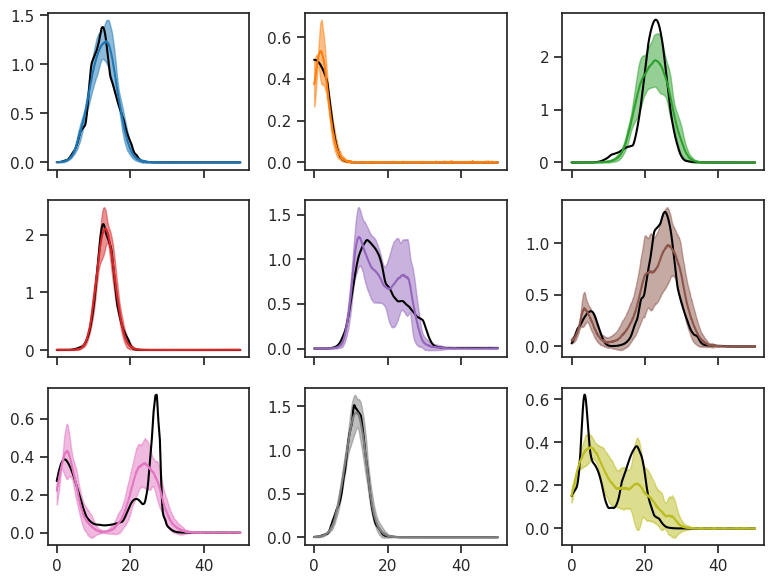

In [6]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    # ax.plot(omega,C_preds[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
tau = test_loader.dataset.laplace.tau
omega = test_loader.dataset.laplace.omega
G_preds_array = np.zeros((C_preds_array.shape[0],C_preds_array.shape[1],len(tau)))
kernel = ( np.exp( -omega * tau[:,None] ) + np.exp( omega * ( tau[:,None] -1 ) ) )/2./np.pi
for spec_num in range(C_preds_array.shape[1]):
    for realization_num in range(C_preds_array.shape[0]):
        G_preds_array[realization_num,spec_num,:] = np.trapz(y=kernel*C_preds_array[realization_num,spec_num,:],x=omega)

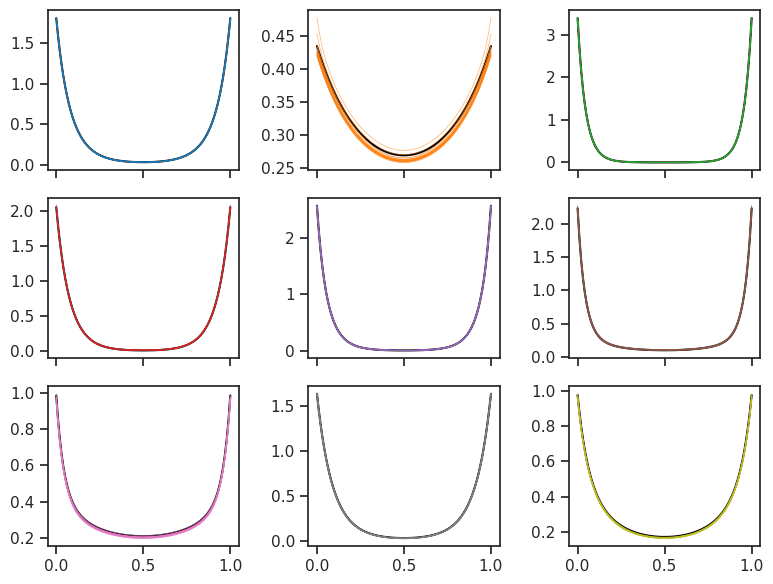

In [8]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(tau,G_test[j].view(99).cpu().detach().numpy(), color='k')
    [ax.plot(tau,G_preds_array[s][j], color=palette[j],alpha=0.6,linewidth=0.5) for s in range(20)]
plt.tight_layout()
plt.show()

In [9]:
#params
kB = 3.1668114E-6  # in Hartree/K
c = 2.99792458E10  # speed of light in cm/s
s_in_t_au = 2.4188843265857E-17  # 1 time a.u. in s

T = 14.0  # in K

b = 1 / (kB * T)
print('beta is ' + str(b))


# rabani input:
Nbeads = 219
Natoms = 180
tau = test_loader.dataset.laplace.tau
# omega_dummy = np.linspace(omega_range[0], omega_range[1], Ng_w)

G_rabani = np.load('data/barak/G_Rabani_' + str(T) + 'K_' + str(Natoms) + 'p.npy')
tau_PIMD = G_rabani[0]
G_rabani = G_rabani[1]

# adds points to G
G_rabani_interp = np.interp(tau, tau_PIMD, G_rabani)
Norm_rabani = np.trapz(G_rabani_interp,tau)*np.pi
G_rabani_interp = G_rabani_interp / Norm_rabani

G_anal_tensor = torch.Tensor(G_rabani_interp)

# rabani output:
import pandas as pd
rabani_data = pd.read_csv("data/Rabani_D_w_14K.csv", sep=",", header=None)
rabani_data_w, rabani_data_D = rabani_data[0].values,rabani_data[1].values
rabani_data_w *= ( 2 * np.pi * c * s_in_t_au * b ) # now omega unitless



# # PIMD with I-pi input:
Nbeads = 50
df=pd.read_csv('/home/sagi/Desktop/parahydrogen/pH2_for_Amit/G_14K_50beads_180p_ipi_sym.csv')
_, G_rabani = df['tau'].values,df['G'].values

# # interpolate - adding points to G
tau_PIMD = np.linspace(0,1,Nbeads+1)
G_rabani_interp_2 = np.interp(tau, tau_PIMD, G_rabani)
Correct_norm = np.trapz(G_rabani_interp_2,tau)*np.pi
G_rabani_interp_2 = G_rabani_interp_2 / Correct_norm 

G_anal_tensor_2 = torch.Tensor(G_rabani_interp_2)

beta is 22555.360078775586


In [27]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_rabani = [diffuser.generate(
        labels= G_anal_tensor.view(1,1,-1).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.01,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani = C_preds_array.mean(0)
C_preds_std_rabani = C_preds_array.std(0)

  0%|          | 0/39 [00:00<?, ?it/s]

100%|██████████| 39/39 [00:00<00:00, 161.96it/s]


In [28]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_rabani = [diffuser.generate(
        labels= G_anal_tensor_2.view(1,1,-1).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.01,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani_2 = C_preds_array.mean(0)
C_preds_std_rabani_2 = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 162.99it/s]


In [25]:
mass=2.01588 # gram/mol
hbar = 1.054571817 * 1E-34 # J * sec = kg * m^2 /sec
hbar *= 1E+20 # kg * angstrom^2 /sec
hbar *= 1E-12 # kg * angstrom^2 /ps
mass /= (1000 * 6.02214076 * 1E+23) # kg
renorm_factor = hbar*3*np.pi/mass

0.3222827264189784
0.32504056074539145
0.2881096360834827


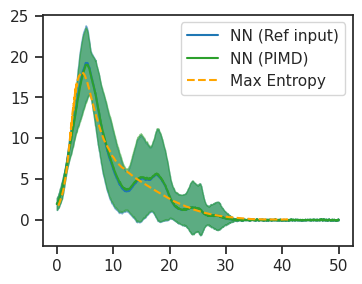

In [29]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,renorm_factor*C_preds_mean_rabani[0],label='NN (Ref input)',color='tab:blue')
ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani[0]-C_preds_std_rabani[0]),renorm_factor*(C_preds_mean_rabani[0]+C_preds_std_rabani[0]),color='tab:blue',alpha=0.5)
print(renorm_factor*C_preds_mean_rabani[0][0]/6)
ax.plot(omega,renorm_factor*C_preds_mean_rabani_2[0],color='tab:green',label='NN (PIMD)')
ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani_2[0]-C_preds_std_rabani_2[0]),renorm_factor*(C_preds_mean_rabani_2[0]+C_preds_std_rabani_2[0]),color='tab:green',alpha=0.5)
print(renorm_factor*C_preds_mean_rabani_2[0][0]/6)
ax.plot(rabani_data_w,rabani_data_D*6,'--',color='orange',label='Max Entropy')
print(rabani_data_D[0])
ax.legend()

Water

In [30]:
velFT = np.loadtxt('/home/sagi/Desktop/water/1bead/nve1/nve_facf.data', usecols=(0,1))
velFT = velFT[velFT[:,0] * 219474<=8000]
water_data_w, water_nve_D = velFT[:,0]* 219474 * ( 2 * np.pi * c * s_in_t_au /kB/300 ), velFT[:,1]
norm_water_nve_D=np.trapz(y=water_nve_D,x=water_data_w)
water_nve_D/=norm_water_nve_D
water_nve_D *= (water_data_w + 1E-30) / (1-np.exp(-water_data_w) + 1E-30)


Nbeads = 32
df=pd.read_csv('/home/sagi/Desktop/water/G_300K_32beads_sym.csv')
_, G_water = df['tau'].values,df['G'].values

G_water_interp = np.interp(tau, np.linspace(0,1,Nbeads+1), G_water)
Norm_water = np.trapz(G_water_interp,tau)*np.pi
G_water_interp = G_water_interp / Norm_water
G_water_tensor = torch.Tensor(G_water_interp)

K = ( np.exp(- water_data_w * tau[:,None]) + np.exp(water_data_w * (tau - 1)[:,None]) )/2/np.pi
G_water_interp2 = np.trapz(y=K*water_nve_D,x=water_data_w)
print(np.trapz(y=G_water_interp2,x=tau)*np.pi)
G_water_tensor2 = torch.Tensor(G_water_interp2)

water_nve_D_interp = np.interp(omega, water_data_w, water_nve_D)

1.000926779558307


In [43]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_water = [(diffuser.generate(
        labels= G_water_tensor.view(1,1,-1).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        constraint_guidance=0.8,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
        prior_knowledge=torch.Tensor(water_nve_D_interp).to('cuda'),
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_water)
C_preds_mean_water = C_preds_array.mean(0)
C_preds_std_water = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 160.58it/s]


In [44]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_water = [(diffuser.generate(
        labels= G_water_tensor2.view(1,1,-1).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        constraint_guidance=0.8,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
        prior_knowledge=torch.Tensor(water_nve_D_interp).to('cuda'),
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_water)
C_preds_mean_water2 = C_preds_array.mean(0)
C_preds_std_water2 = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 162.63it/s]


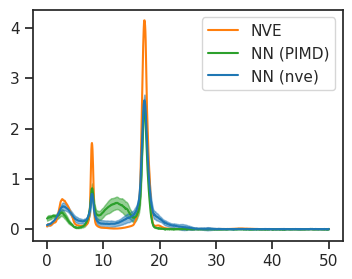

In [ ]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,water_nve_D_interp,color='tab:orange',label='NVE')
ax.plot(omega,C_preds_mean_water[0],label='NN (PIMD)',color='tab:green')
ax.fill_between(omega,(C_preds_mean_water[0]-C_preds_std_water[0]),(C_preds_mean_water[0]+C_preds_std_water[0]),color='tab:green',alpha=0.5)
ax.plot(omega,C_preds_mean_water2[0],label='NN (nve)',color='tab:blue')
ax.fill_between(omega,(C_preds_mean_water2[0]-C_preds_std_water2[0]),(C_preds_mean_water2[0]+C_preds_std_water2[0]),color='tab:blue',alpha=0.5)

ax.legend()

# Pointwise Normalization of G
G has 4 channels

In [2]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(omega_domain=(0,50),num_bumps_range=(1,4),bump_widths_fraction_range=(0.1, 0.6),bump_centers_fraction_range=(0.0, 0.5)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256),
    train_config=TrainConfig(compile=False, lr=3e-5, batch_size=50,n_epoch=800,use_wandb=True,save_model=True,model_name='pointwise_norm_G_Csigma0.1-0.6_B')
    )
# model = main(model_cfg, pointwise_norm=True)

In [3]:
from tld.denoiser import Denoiser
model = Denoiser(**asdict(model_cfg.denoiser_config))
model.load_state_dict(torch.load('pointwise_norm_G_Csigma0.1-0.6_B',map_location=torch.device('cuda'))["model_ema"])

<All keys matched successfully>

In [32]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(omega_domain=(0,50),num_bumps_range=(1,4),bump_widths_fraction_range=(0.1, 0.45)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256),
    train_config=TrainConfig(
        compile=False, 
        lr=3e-5, 
        batch_size=50,
        n_epoch=2000,
        use_wandb=True,
        save_model=True,
        model_name='pointwise_norm_G',
        from_scratch=False,
        run_id = '7d56paic'
    )
)
model = main(model_cfg, pointwise_norm=True)

Creating training loader:
Loading Model:
model prep


/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


The model has 11383564 parameters


100%|██████████| 400/400 [01:29<00:00,  4.47it/s]


epoch: 1 | train_loss: 0.01566526207025163


...

100%|██████████| 400/400 [01:35<00:00,  4.19it/s]


epoch: 1999 | train_loss: 0.007277586838463321


100%|██████████| 400/400 [01:34<00:00,  4.22it/s]

epoch: 2000 | train_loss: 0.007422265379573218


train_loss,█▆▇▇▆▅▅▄▄▄▄▄▄▄▃▃▃▃▅▃▃▂▂▂▂▃▃▃▂▂▂▂▂▁▁▂▂▂▁▁
train_loss,0.00742


In [4]:
# hparams = asdict(model_cfg.data_config)
hparams = {
    'omega_domain': (0, 50.0),
    'num_bumps_range': (1,4), 
    'bump_widths_fraction_range': (0.1, 0.45), 
    'bump_centers_fraction_range': (0.0, 0.6)
}
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9, pointwise_norm=True)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 4, 99])


In [33]:
# enc_G = pointwise_G_normalization(mean=torch.Tensor([ 3.3555e-01, -2.2111e+00, -1.2480e-03,  5.0047e-01]), std=torch.Tensor([0.4986, 2.0547, 1.1408, 0.2882]))
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list = [diffuser.generate(
        labels= (G_test).to('cuda'),
        num_specs=9,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.1,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
        # prior_knowledge=C_test.to('cuda'),
        # directed_positivity=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(100)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

  0%|          | 0/39 [00:00<?, ?it/s]

100%|██████████| 39/39 [00:01<00:00, 21.55it/s]


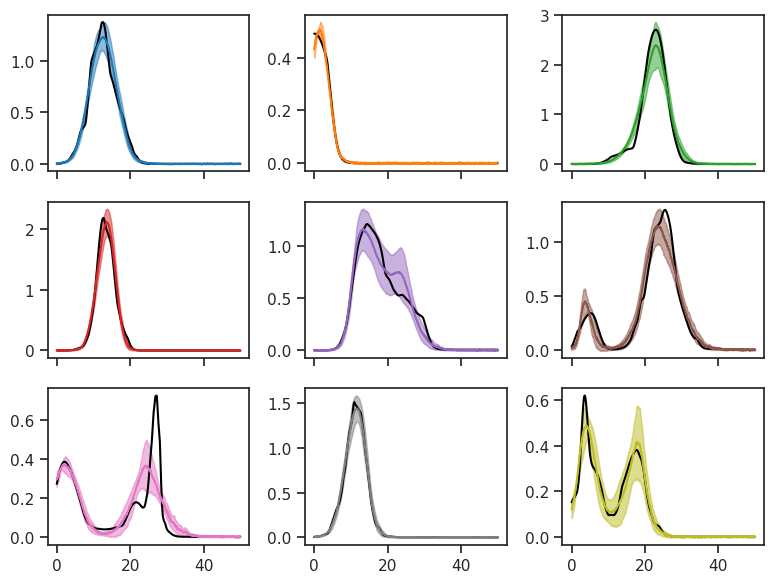

In [34]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    # ax.plot(omega,C_preds[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

In [53]:
tau = test_loader.dataset.laplace.tau
omega = test_loader.dataset.laplace.omega
sfm_spec = SoftmaxMean(pred_spectra=C_preds_array, ground_truth_G=G_test, tau=tau, omega=omega)
weighted_spec = sfm_spec.softmax_mean_spectra(beta=1000000.).numpy()

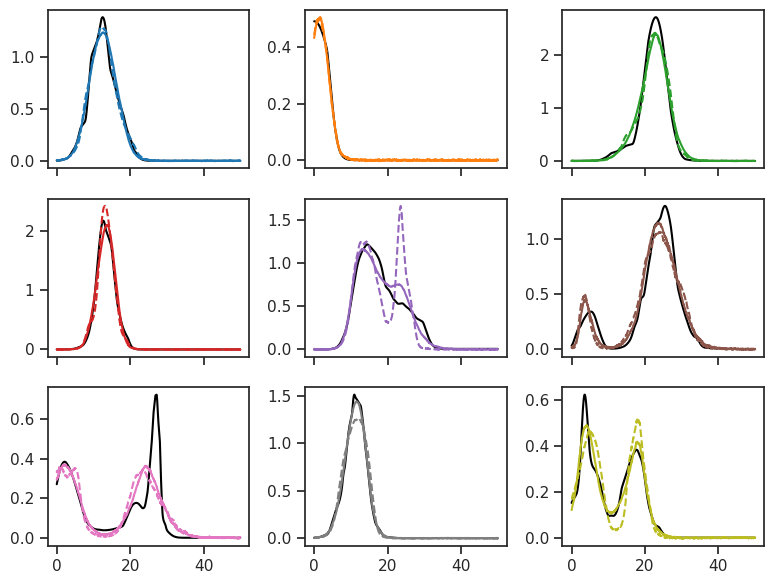

In [54]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.plot(omega,weighted_spec[j],'--', color=palette[j])
    # ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

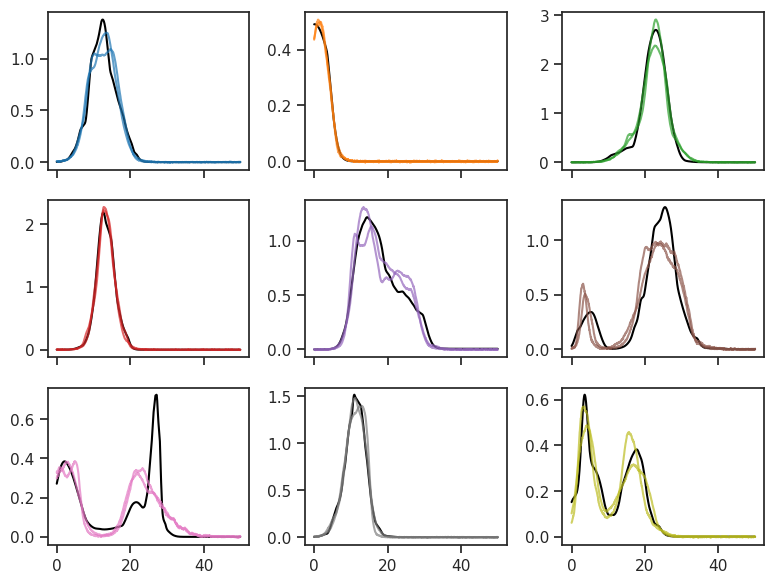

In [21]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    for i in range(2,4):
        ax.plot(omega,C_preds_array[i][j], color=palette[j], alpha=0.7)
    # ax.plot(omega,C_preds_mean[j], color=palette[j])
    # ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
tau = test_loader.dataset.laplace.tau
omega = test_loader.dataset.laplace.omega
G_preds_array = np.zeros((C_preds_array.shape[0],C_preds_array.shape[1],len(tau)))
kernel = ( np.exp( -omega * tau[:,None] ) + np.exp( omega * ( tau[:,None] -1 ) ) )/2./np.pi
for spec_num in range(C_preds_array.shape[1]):
    for realization_num in range(C_preds_array.shape[0]):
        G_preds_array[realization_num,spec_num,:] = np.trapz(y=kernel*C_preds_array[realization_num,spec_num,:],x=omega)

In [11]:
enc_G = pointwise_G_normalization(mean=torch.Tensor([ 0.3319, -1.8394,  0.0023,  0.5002]), std=torch.Tensor([0.4170, 1.5327, 1.1582, 0.2884]))
G_preds_tensor = enc_G(torch.Tensor(G_preds_array))
G_preds_tensor.shape

torch.Size([20, 9, 4, 99])

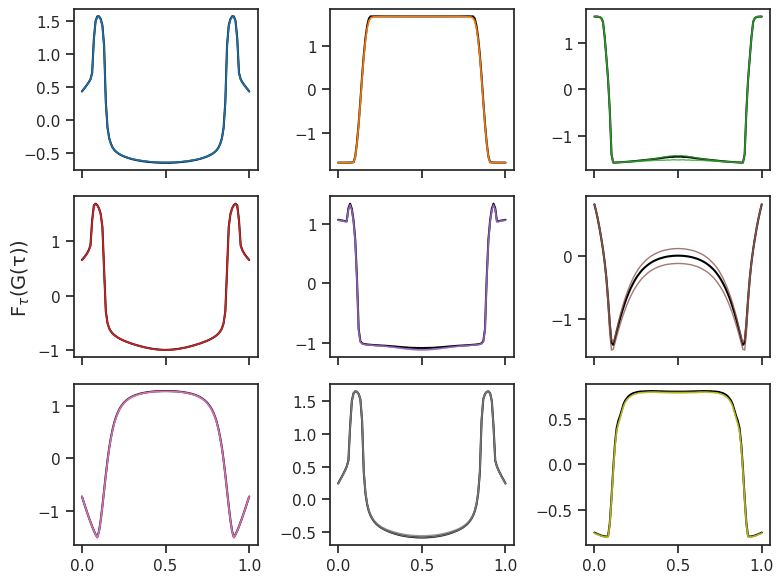

In [31]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(tau,G_test[j][3].view(99).cpu().detach().numpy(), color='k')
    [ax.plot(tau,G_preds_tensor[s][j][3].numpy(), color=palette[j],alpha=0.8,linewidth=1.) for s in range(2,4)]
    if j==3:
        # ax.set_ylabel('log(G(τ))')
        # ax.set_ylabel('G(τ))')
        ax.set_ylabel(r'F$_τ$(G(τ))')
plt.tight_layout()
plt.show()

In [240]:
#params
kB = 3.1668114E-6  # in Hartree/K
c = 2.99792458E10  # speed of light in cm/s
s_in_t_au = 2.4188843265857E-17  # 1 time a.u. in s

T = 14.0  # in K

b = 1 / (kB * T)
print('beta is ' + str(b))


# rabani input:
Nbeads = 219
Natoms = 180
tau = test_loader.dataset.laplace.tau
# omega_dummy = np.linspace(omega_range[0], omega_range[1], Ng_w)

G_rabani = np.load('data/barak/G_Rabani_' + str(T) + 'K_' + str(Natoms) + 'p.npy')
tau_PIMD = G_rabani[0]
G_rabani = G_rabani[1]

# adds points to G
G_rabani_interp = np.interp(tau, tau_PIMD, G_rabani)
Norm_rabani = np.trapz(G_rabani_interp,tau)*np.pi
G_rabani_interp = G_rabani_interp / Norm_rabani

G_anal_tensor = torch.Tensor(G_rabani_interp)

# rabani output:
import pandas as pd
rabani_data = pd.read_csv("data/Rabani_D_w_14K.csv", sep=",", header=None)
rabani_data_w, rabani_data_D = rabani_data[0].values,rabani_data[1].values
rabani_data_w *= ( 2 * np.pi * c * s_in_t_au * b ) # now omega unitless

rabani_D_interp = np.interp(omega, rabani_data_w, rabani_data_D)
rabani_D_interp/= np.trapz(y=rabani_D_interp * (1-np.exp(-omega) + 1e-30)/(omega + 1e-30),x=omega)

# # PIMD with I-pi input:
Nbeads = 50
df=pd.read_csv('/home/sagi/Desktop/parahydrogen/pH2_for_Amit/G_14K_50beads_180p_ipi_sym.csv')
_, G_rabani = df['tau'].values,df['G'].values

# # interpolate - adding points to G
tau_PIMD = np.linspace(0,1,Nbeads+1)
G_rabani_interp_2 = np.interp(tau, tau_PIMD, G_rabani)
Correct_norm = np.trapz(G_rabani_interp_2,tau)*np.pi
G_rabani_interp_2 = G_rabani_interp_2 / Correct_norm 

G_anal_tensor_2 = torch.Tensor(G_rabani_interp_2)

beta is 22555.360078775586


In [242]:
enc_G = pointwise_G_normalization(mean=torch.Tensor([ 0.3319, -1.8394,  0.0023,  0.5002]), std=torch.Tensor([0.4170, 1.5327, 1.1582, 0.2884]))
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_rabani = [diffuser.generate(
        labels= enc_G(G_anal_tensor.view(1,-1)).unsqueeze(0).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.01,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani = C_preds_array.mean(0)
C_preds_std_rabani = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 158.22it/s]


In [243]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_rabani = [diffuser.generate(
        labels= enc_G(G_anal_tensor_2.view(1,-1)).unsqueeze(0).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.01,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani_2 = C_preds_array.mean(0)
C_preds_std_rabani_2 = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 159.31it/s]


In [244]:
mass=2.01588 # gram/mol
hbar = 1.054571817 * 1E-34 # J * sec = kg * m^2 /sec
hbar *= 1E+20 # kg * angstrom^2 /sec
hbar *= 1E-12 # kg * angstrom^2 /ps
mass /= (1000 * 6.02214076 * 1E+23) # kg
renorm_factor = hbar*3*np.pi/mass

0.5181458170352741
0.5655622135955461
0.2881096360834827


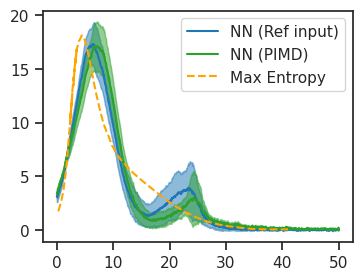

In [245]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,renorm_factor*C_preds_mean_rabani[0],label='NN (Ref input)',color='tab:blue')
ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani[0]-C_preds_std_rabani[0]),renorm_factor*(C_preds_mean_rabani[0]+C_preds_std_rabani[0]),color='tab:blue',alpha=0.5)
print(renorm_factor*C_preds_mean_rabani[0][0]/6)
ax.plot(omega,renorm_factor*C_preds_mean_rabani_2[0],color='tab:green',label='NN (PIMD)')
ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani_2[0]-C_preds_std_rabani_2[0]),renorm_factor*(C_preds_mean_rabani_2[0]+C_preds_std_rabani_2[0]),color='tab:green',alpha=0.5)
print(renorm_factor*C_preds_mean_rabani_2[0][0]/6)
ax.plot(rabani_data_w,rabani_data_D*6,'--',color='orange',label='Max Entropy')
print(rabani_data_D[0])
ax.legend()

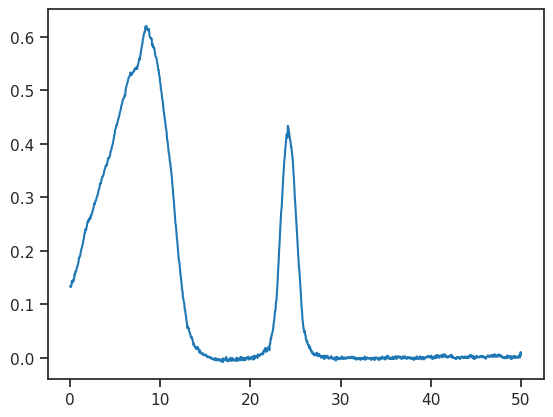

In [277]:
plt.plot(omega,C_preds_array[17][0])

In [330]:
n = 1024
laplac_mat = np.fromfunction(lambda i, j: ((i == j) * (2 - ((i == 0) | (i == n-1)))) + ((np.abs(i - j) == 1) * -1), (n, n), dtype=int)
U, s, VT = np.linalg.svd(test_loader.dataset.laplace.kernel/2./np.pi*omega[1])
G_hat = U[:,:10]@U[:,:10].T@G_rabani_interp
from qpsolvers import solve_qp

# for i in range(20):
#     x=solve_qp(P=np.eye(1024),q=-C_preds_array[i][0],A=test_loader.dataset.laplace.kernel/2./np.pi*omega[1],
#                b=G_hat,lb=np.zeros(1024),solver='proxqp',max_iter=10000)
#     if x is None:
#         print('QP failed')
#     else:
#         print(i)
x=solve_qp(P=np.eye(1024)+1e-3*laplac_mat,q=-(C_preds_mean_rabani_2[0]),A=test_loader.dataset.laplace.kernel/2./np.pi*omega[1],
           b=G_hat,lb=np.zeros(1024),solver='proxqp',max_iter=10000,verbose=True)
if x is None:
    print('########################')
    print('########################')
    print('QP failed')
    print('########################')
    print('########################')

-------------------------------------------------------------------------------------------------

                              ProxQP - Primal-Dual Proximal QP Solver
     (c) Antoine Bambade, Sarah El Kazdadi, Fabian Schramm, Adrien Taylor, and Justin Carpentier
                                         Inria Paris 2022        

-------------------------------------------------------------------------------------------------

problem:  
          variables n = 1024, equality constraints n_eq = 99,
          inequality constraints n_in = 1024
settings: 
          backend = dense,
          eps_abs = 1.00e-05 eps_rel = 0.00e+00
          eps_prim_inf = 1.00e-04, eps_dual_inf = 1.00e-04,
          rho = 1.00e-06, mu_eq = 1.00e-03, mu_in = 1.00e-01,
          max_iter = 10000, max_iter_in = 1500,
          box constraints: off, 
          dense backend: PrimalDualLDLT, 
          problem type: Quadratic Program, 
          scaling: on, 
          timings: off, 
          initial guess: e

In [326]:
x

ValueError: x, y, and format string must not be None

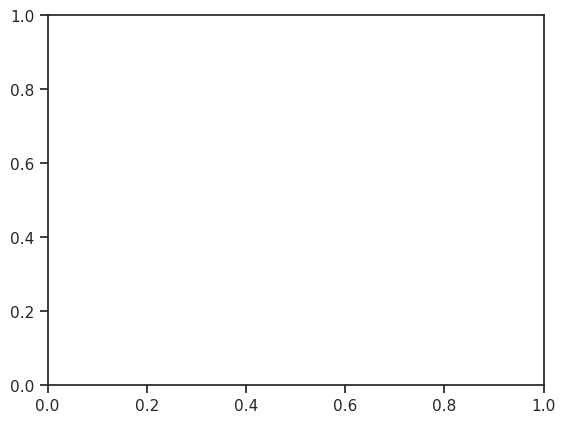

In [303]:
plt.plot(x)
plt.plot(C_preds_mean_rabani_2[0])

In [ ]:
CDFs = torch.from_numpy(C_preds_array).cumsum(dim=-1)
CDFs = CDFs / CDFs[:, :, -1].unsqueeze(-1)
rabani_CDF = torch.from_numpy(rabani_D_interp).view(1, 1, -1).cumsum(dim=-1)
rabani_CDF = rabani_CDF / rabani_CDF[:, :, -1].unsqueeze(-1)
wdist = (torch.abs(CDFs - rabani_CDF)).mean(dim=-1).squeeze(1)

In [23]:
sorted_indices = torch.argsort(wdist)[:20]
top_similar_spectra = C_preds_array[sorted_indices.numpy(),0,:]

In [20]:
top_similar_spectra.shape

(20, 1024)

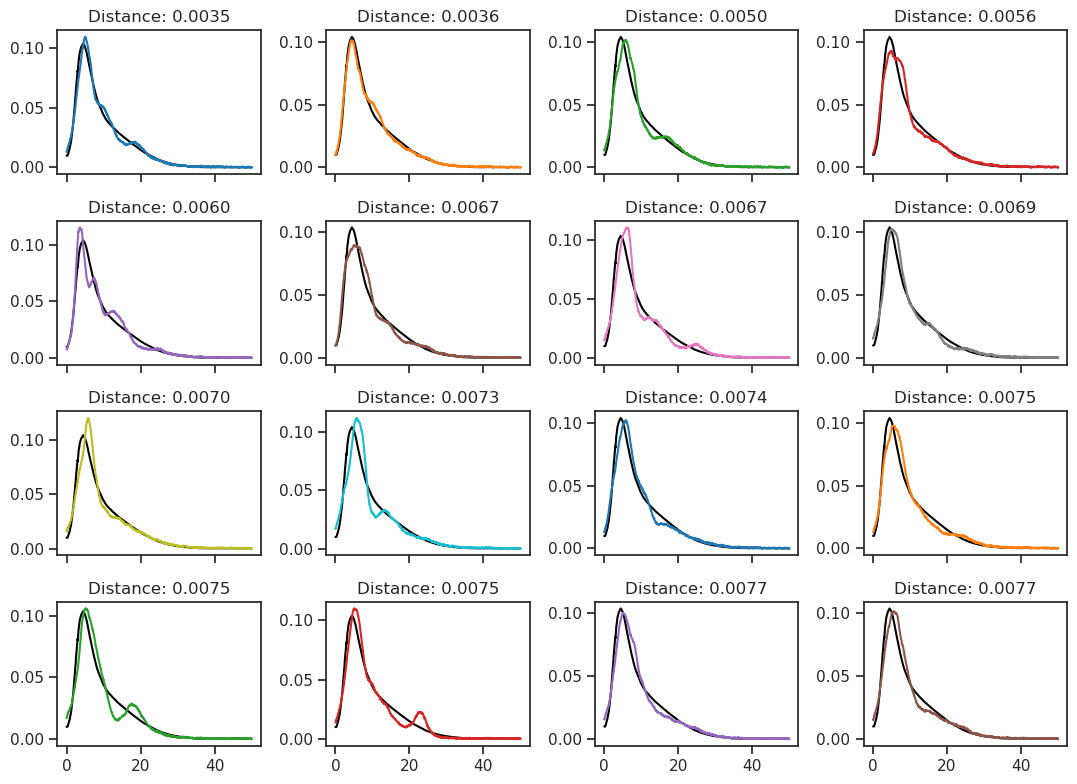

In [24]:
norm_spect=True
n = int(np.sqrt(len(sorted_indices)))
fig,axs = plt.subplots(n,n,figsize=(8.2*n/3,6*n/3),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
for j, ax in enumerate(axs.flatten()):
    y = rabani_D_interp
    if norm_spect:
        y /= np.trapz(y, x=omega)
    ax.plot(omega, y, color='k')
    y = top_similar_spectra[j]
    if norm_spect:
        y /= np.trapz(y, x=omega)
    ax.plot(omega, y, color=palette[j])
    ax.set_title(f"Distance: {wdist[sorted_indices[j]].item():.4f}")
plt.tight_layout()
plt.show()

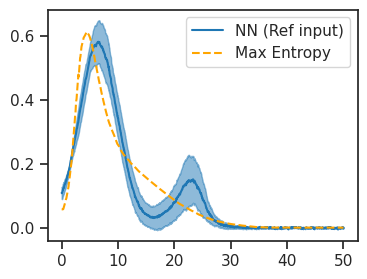

In [15]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,C_preds_mean_rabani[0],label='NN (Ref input)',color='tab:blue')
ax.fill_between(omega,(C_preds_mean_rabani[0]-C_preds_std_rabani[0]),(C_preds_mean_rabani[0]+C_preds_std_rabani[0]),color='tab:blue',alpha=0.5)
ax.plot(omega,rabani_D_interp,'--',color='orange',label='Max Entropy')
ax.legend()

water

In [11]:
velFT = np.loadtxt('/home/sagi/Desktop/water/1bead/nve1/nve_facf.data', usecols=(0,1))
velFT = velFT[velFT[:,0] * 219474<=8000]
water_data_w, water_nve_D = velFT[:,0]* 219474 * ( 2 * np.pi * c * s_in_t_au /kB/300 ), velFT[:,1]
norm_water_nve_D=np.trapz(y=water_nve_D,x=water_data_w)
water_nve_D/=norm_water_nve_D
water_nve_D *= (water_data_w + 1E-30) / (1-np.exp(-water_data_w) + 1E-30)


Nbeads = 32
df=pd.read_csv('/home/sagi/Desktop/water/G_300K_32beads_sym.csv')
_, G_water = df['tau'].values,df['G'].values

G_water_interp = np.interp(tau, np.linspace(0,1,Nbeads+1), G_water)
Norm_water = np.trapz(G_water_interp,tau)*np.pi
G_water_interp = G_water_interp / Norm_water
G_water_tensor = torch.Tensor(G_water_interp)

K = ( np.exp(- water_data_w * tau[:,None]) + np.exp(water_data_w * (tau - 1)[:,None]) )/2/np.pi
G_water_interp2 = np.trapz(y=K*water_nve_D,x=water_data_w)
print(np.trapz(y=G_water_interp2,x=tau)*np.pi)
G_water_tensor2 = torch.Tensor(G_water_interp2)

water_nve_D_interp = np.interp(omega, water_data_w, water_nve_D)

1.000926779558307


In [12]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_water = [(diffuser.generate(
        labels= enc_G(G_water_tensor.view(1,-1)).unsqueeze(0).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.8,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
        # prior_knowledge=torch.Tensor(water_nve_D_interp).to('cuda'),
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_water)
C_preds_mean_water = C_preds_array.mean(0)
C_preds_std_water = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 133.34it/s]


In [13]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_water = [(diffuser.generate(
        labels= enc_G(G_water_tensor2.view(1,-1)).unsqueeze(0).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.8,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
        # prior_knowledge=torch.Tensor(water_nve_D_interp).to('cuda'),
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_water)
C_preds_mean_water2 = C_preds_array.mean(0)
C_preds_std_water2 = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 158.79it/s]


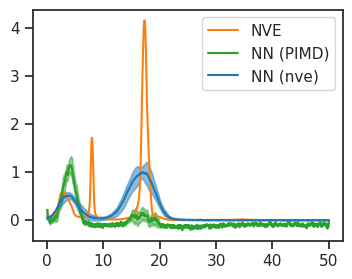

In [14]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,water_nve_D_interp,color='tab:orange',label='NVE')
ax.plot(omega,C_preds_mean_water[0],label='NN (PIMD)',color='tab:green')
ax.fill_between(omega,(C_preds_mean_water[0]-C_preds_std_water[0]),(C_preds_mean_water[0]+C_preds_std_water[0]),color='tab:green',alpha=0.5)
ax.plot(omega,C_preds_mean_water2[0],label='NN (nve)',color='tab:blue')
ax.fill_between(omega,(C_preds_mean_water2[0]-C_preds_std_water2[0]),(C_preds_mean_water2[0]+C_preds_std_water2[0]),color='tab:blue',alpha=0.5)

ax.legend()

In [4]:
tau = test_loader.dataset.laplace.tau
omega = test_loader.dataset.laplace.omega
K = ( torch.exp( -torch.Tensor(omega * tau[:,None]) ) + torch.exp( torch.Tensor(omega * ( tau[:,None] -1 )) ) )/2./np.pi*omega[1]
U,s,VT = torch.linalg.svd(K)
# K_T = K.T #K.transpose(1,0)
# KK = K_T@K
# predicted_D =(m*np.exp(VT[:20,:].T@x)) 

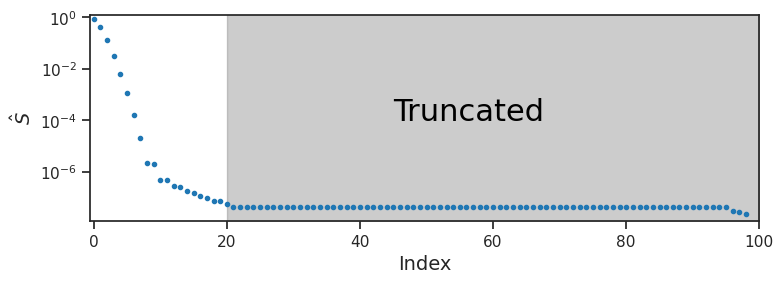

In [115]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(s[:].numpy(),'.') #, ax.axvline(20,linestyle='--', color='gray'), 
ax.fill_betweenx(y=[1e-8,1.5],x1=20,x2=100,color='gray',alpha=0.4)
ax.set_yscale('log') , ax.text(45, 1e-4, 'Truncated', color='k', size=22)
ax.set_ylabel(r'$\hat{S}$'), ax.set_xlabel(r'Index')
ax.set_xlim(-0.5, 100), ax.set_ylim(min(s)*0.5, max(s)*1.5)
plt.tight_layout()

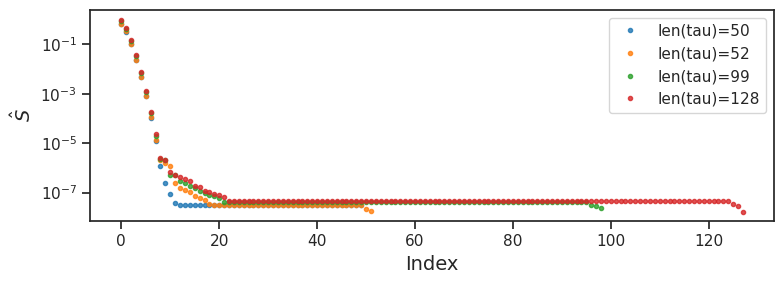

In [297]:
fig, ax = plt.subplots(figsize=(8, 3))
for bins in [50,52,99,128]:
    KK = ( torch.exp( -torch.Tensor(omega * np.linspace(0, 1, bins)[:,None]) ) + torch.exp( torch.Tensor(omega * ( np.linspace(0, 1, bins)[:,None] -1 )) ) )/2./np.pi*omega[1]
    UU,ss,VVT = torch.linalg.svd(KK)
    ax.plot(ss[:].numpy(),'.',label=f'len(tau)={bins}',alpha=0.8)
ax.set_yscale('log')
ax.set_ylabel(r'$\hat{S}$'), ax.set_xlabel(r'Index')
ax.legend()
plt.tight_layout()

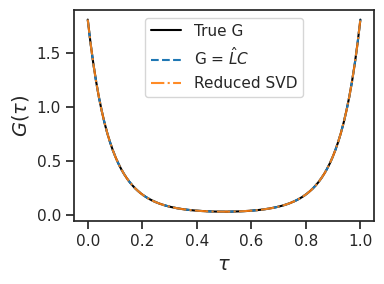

In [136]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(tau, G_test[0][0].view(99).numpy()*0.4170+0.3319, label='True G', color='k')
ax.plot(tau, K@C_test[0].view(1024).numpy(), '--', label=r'G = $\hat{L}C$', color='tab:blue')
ax.plot(tau, (U[:,:20]@torch.diag(s[:20])@VT[:20,:])@C_test[0].view(1024).numpy(),'-.', label='Reduced SVD', color='tab:orange',alpha=0.9)
ax.set_xlabel(r'$\tau$'), ax.set_ylabel(r'$G(\tau)$')
ax.legend()
plt.tight_layout()

In [145]:
(VT[:20,:].T@torch.diag(1/s[:20])@U[:,:20].T).shape

torch.Size([1024, 99])

In [193]:
(VT.T[:,:20]@VT[:20,:]).shape#diag()

torch.Size([1024, 1024])

In [171]:
def Q_lambda(x):
    return torch.diag((x*s[:20]**2)/(1+x*s[:20]**2))
def R_lambda(x):
    return torch.diag((x*s[:20])/(1+x*s[:20]**2))

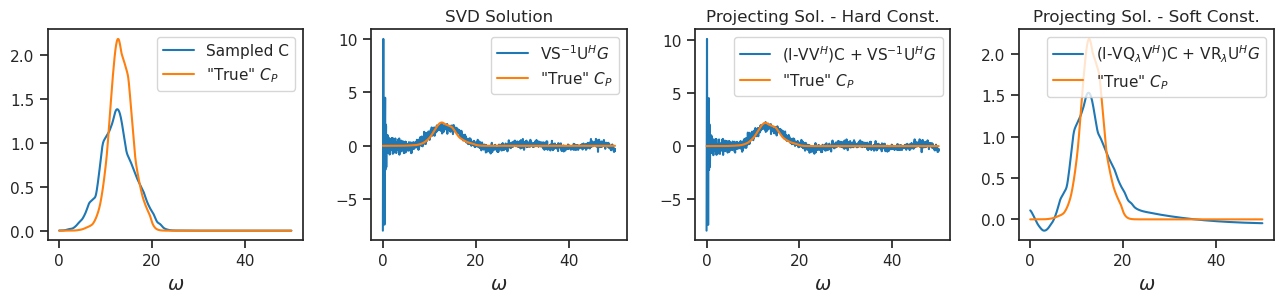

In [243]:
fig, ax = plt.subplots(1,4,figsize=(13, 3.2))
# ax.plot(tau,G_test[0][0].view(99).numpy()*0.4170+0.3319)
# ax.plot(tau,G_test[3][0].view(99).numpy()*0.4170+0.3319)
ax[0].plot(omega,C_test[0].view(1024).numpy(), label='Sampled C', color='tab:blue')
# ax[0].plot(omega,C_test[3].view(1024).numpy(), label=r'"True" $C_P$', color='tab:orange')
ax[1].set_title('SVD Solution')
ax[1].plot(omega, (VT[:20,:].T@torch.diag(1/s[:20])@U[:,:20].T@(G_test[3][0].view(99)*0.4170+0.3319)).numpy(), label=r'VS$^{-1}$U$^{H}G$')
ax[2].set_title('Projecting Sol. - Hard Const.')
ax[2].plot(omega,((torch.eye(1024)-VT[:20,:].T@VT[:20,:])@C_test[0].view(1024)).numpy()+
           (VT[:20,:].T@torch.diag(1/s[:20])@U[:,:20].T@(G_test[3][0].view(99)*0.4170+0.3319)).numpy(), label=r'(I-VV$^H$)C + VS$^{-1}$U$^{H}G$'
           )
ax[3].set_title('Projecting Sol. - Soft Const.')
ax[3].plot(omega,((torch.eye(1024)-VT[:20,:].T@Q_lambda(1e4)@VT[:20,:])@C_test[0].view(1024)).numpy()+
           (VT[:20,:].T@R_lambda(1e4)@U[:,:20].T@(G_test[3][0].view(99)*0.4170+0.3319)).numpy(), label=r'(I-VQ$_{\lambda}$V$^H$)C + VR$_{\lambda}$U$^{H}G$'
           )
for i in range(4):
    ax[i].plot(omega,C_test[3].view(1024).numpy(), label=r'"True" $C_P$', color='tab:orange')
    ax[i].set_xlabel(r'$\omega$')
    ax[i].legend()
plt.tight_layout()

In [256]:
labels[1]

'10$^{10}$'

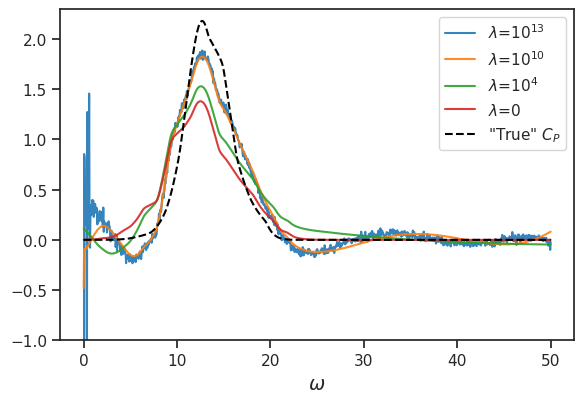

In [275]:
fig, ax = plt.subplots(figsize=(6, 4.2))
labels = ['10$^{13}$','10$^{10}$','10$^{4}$','0']
# ax.plot(omega,C_test[0].view(1024).numpy(), label='Sampled C', color='k')
for i,k in enumerate([1e13,1e10,1e4,0]):
    ax.plot(omega,((torch.eye(1024)-VT[:20,:].T@Q_lambda(k)@VT[:20,:])@C_test[0].view(1024)).numpy()+
           (VT[:20,:].T@R_lambda(k)@U[:,:20].T@(G_test[3][0].view(99)*0.4170+0.3319)).numpy(), label=r'$\lambda$='+labels[i], alpha=0.9
           )
ax.plot(omega,C_test[3].view(1024).numpy(),'--', label=r'"True" $C_P$', color='k')
ax.legend()
ax.set_xlabel(r'$\omega$')
ax.set_ylim(-1,2.3)
plt.tight_layout()

In [151]:
n = 1024
laplac_mat = np.fromfunction(lambda i, j: ((i == j) * (2 - ((i == 0) | (i == n-1)))) + ((np.abs(i - j) == 1) * -1), (n, n), dtype=int)

In [286]:
G_hat = ((U[:,:10]@U[:,:10].T)@(G_test[3][0].view(99))).numpy()*0.4170+0.3319

In [287]:
from qpsolvers import solve_qp

x=solve_qp(P=np.eye(1024),q=-C_test[0].view(1024).numpy(),A=K.numpy(),b=G_hat,lb=np.zeros(1024),solver='proxqp',max_iter=10000,verbose=True)
if x is None:
    print('QP failed')

-------------------------------------------------------------------------------------------------

                              ProxQP - Primal-Dual Proximal QP Solver
     (c) Antoine Bambade, Sarah El Kazdadi, Fabian Schramm, Adrien Taylor, and Justin Carpentier
                                         Inria Paris 2022        

-------------------------------------------------------------------------------------------------

problem:  
          variables n = 1024, equality constraints n_eq = 99,
          inequality constraints n_in = 1024
settings: 
          backend = dense,
          eps_abs = 1.00e-05 eps_rel = 0.00e+00
          eps_prim_inf = 1.00e-04, eps_dual_inf = 1.00e-04,
          rho = 1.00e-06, mu_eq = 1.00e-03, mu_in = 1.00e-01,
          max_iter = 10000, max_iter_in = 1500,
          box constraints: off, 
          dense backend: PrimalDualLDLT, 
          problem type: Quadratic Program, 
          scaling: on, 
          timings: off, 
          initial guess: e

In [ ]:
# x=solve_qp(P=np.eye(1024),q=-x,A=K.numpy(),b=G_hat,lb=np.zeros(1024),solver='proxqp',max_iter=10000)

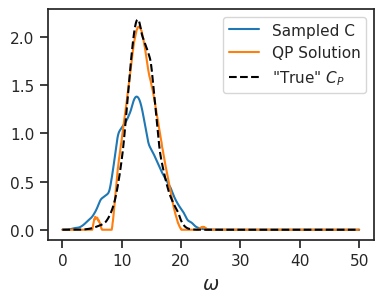

In [288]:
fig, ax = plt.subplots(figsize=(4, 3.2))
ax.plot(omega,C_test[0].view(1024).numpy(), label='Sampled C', color='tab:blue')
ax.plot(omega,x, label='QP Solution', color='tab:orange')
ax.plot(omega,C_test[3].view(1024).numpy(),'--', label=r'"True" $C_P$', color='k')
ax.set_xlabel(r'$\omega$')
ax.legend()
plt.tight_layout()

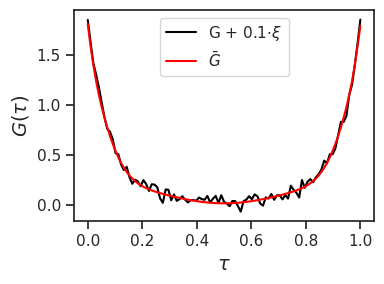

In [205]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(tau, (G_test[0][0].view(99)+0.1*torch.randn(99)).numpy()*0.4170+0.3319, label=r'G + 0.1$\cdot\xi$', color='k')
ax.plot(tau, (((U[:,:10]@U[:,:10].T)@(G_test[0][0].view(99)+0.1*torch.randn(99))).numpy()*0.4170+0.3319), label=r'$\bar{G}$', color='r')
ax.set_xlabel(r'$\tau$'), ax.set_ylabel(r'$G(\tau)$')
ax.legend()
plt.tight_layout()

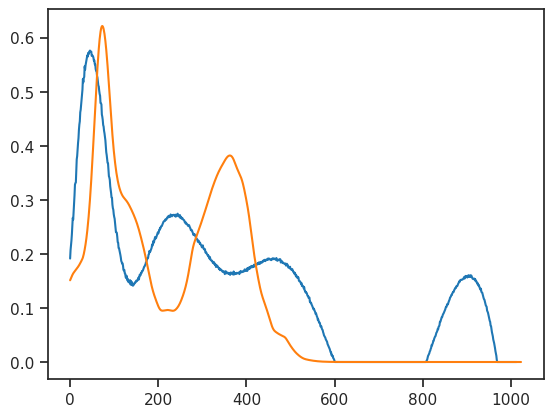

In [93]:
U,s,VT = torch.linalg.svd(K)
plt.plot( torch.relu(VT[:10,:].T@torch.diag(1/s[:10])@U[:,:10].T @ (G_test[8]+0.00001*torch.randn_like(G_test[8])).view(99)).numpy()[10:] )
plt.plot(C_test[8].view(1024).cpu().detach().numpy())

In [41]:
(VT[:,:30].T@VT[:,:30]).shape

torch.Size([30, 30])

RuntimeError: size mismatch, got 30, 30x30,1024

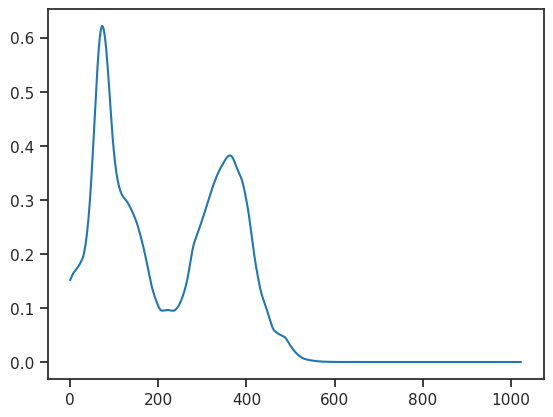

In [34]:
plt.plot(C_test[8].view(1024).numpy())
plt.plot(((VT[:30]@VT[:30].T)@C_test[8].view(1024)).numpy())

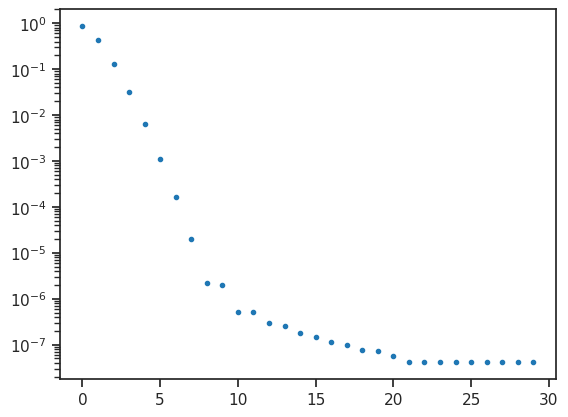

In [27]:
U,s,VT = torch.linalg.svd(K)
plt.plot(s[:30].cpu().detach().numpy(),'.')
# U,s,VT = torch.linalg.svd(KK)
# plt.plot(s[:30].cpu().detach().numpy())
plt.yscale('log')

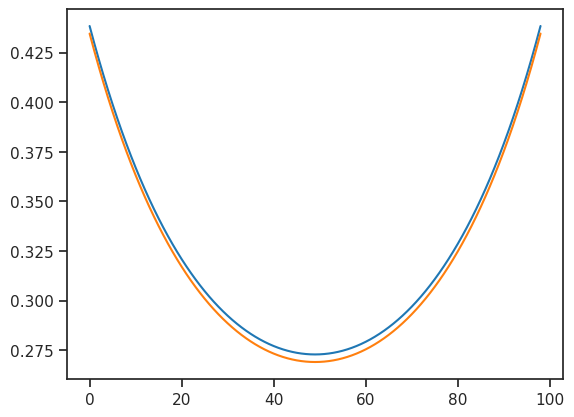

In [118]:
plt.plot((K@C_test.squeeze(1)[1]).cpu().detach().numpy())
plt.plot(G_test[1].view(99).cpu().detach().numpy())

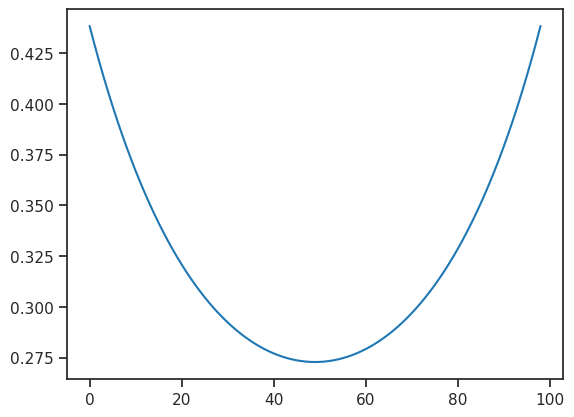

In [139]:
plt.plot(((C_test@K.transpose(1,0))[1].view(99)).cpu().detach().numpy())

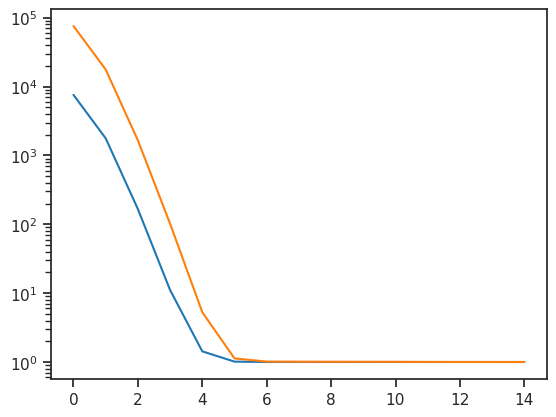

In [8]:
eps=10000
U,s,VT = torch.linalg.svd(torch.eye(KK.shape[0])+eps*KK)
plt.plot(s[:15])
eps=100000
U,s,VT = torch.linalg.svd(torch.eye(KK.shape[0])+eps*KK)
plt.plot(s[:15])

plt.yscale('log')

In [34]:
temp = torch.relu( (VT.T@torch.diag(1/s)@U.T) @( (C_test.squeeze(1)[6]) + eps*K_T@G_test.squeeze(1)[6] ) )
for i in range(5):
    temp = torch.relu( (VT.T@torch.diag(1/s)@U.T) @( temp + eps*K_T@G_test.squeeze(1)[6] ) )

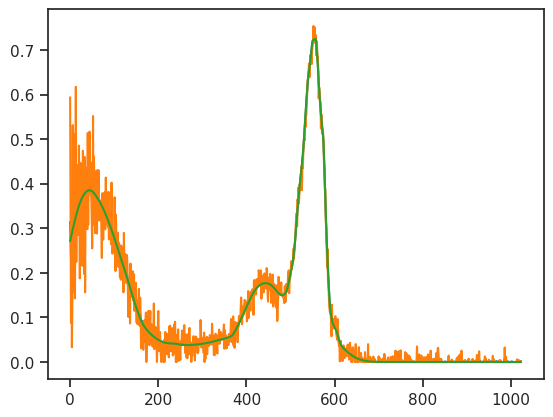

In [36]:
plt.plot(torch.relu( (VT.T@torch.diag(1/s)@U.T) @((C_test.squeeze(1)[6]+0.*torch.randn_like(C_test.squeeze(1)[6]))+eps*K_T@G_test.squeeze(1)[6]) ))
plt.plot(temp.cpu().detach().numpy())
plt.plot(C_test.squeeze(1)[6])

In [187]:
U,s,VT = torch.linalg.svd(K)
m = 50 * VT@( C_test.squeeze(1)[8]* (K_T@(G_test.squeeze(1)[6]- K@C_test.squeeze(1)[8] )) ) 
for i in range(20):
    m = m+ 50*VT@( C_test.squeeze(1)[8]*torch.exp(VT.T@m)* (K_T@(G_test.squeeze(1)[6]- K@(C_test.squeeze(1)[8]*torch.exp(VT.T@m)) )) ) 

In [220]:
temp = C_test.squeeze(1)[6] + 10*K_T@(G_test.squeeze(1)[8]+0.01*torch.randn_like(G_test.squeeze(1)[8])-K@(C_test.squeeze(1)[6]))
# for i in range(1000):
#     temp = torch.relu(temp + 1*K_T@(G_test.squeeze(1)[8]+0.01*torch.randn_like(G_test.squeeze(1)[8])-K@temp))

In [225]:
temp = C_test + 10*(G_test.squeeze(1)[8]+0.01*torch.randn_like(G_test.squeeze(1)[8])-C_test@K_T )@ K
temp.shape

torch.Size([9, 1, 1024])

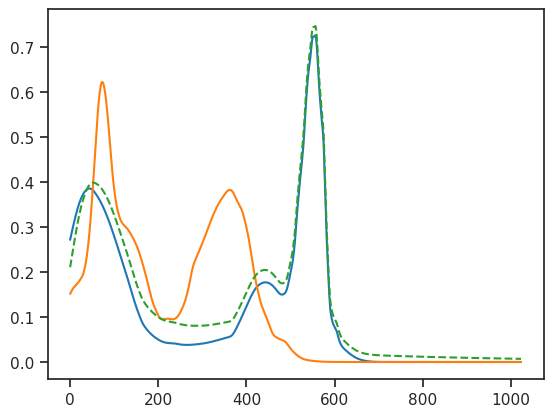

In [226]:
plt.plot(C_test.squeeze(1)[6].cpu().detach().numpy())
plt.plot(C_test.squeeze(1)[8].cpu().detach().numpy())
# plt.plot(C_test.squeeze(1)[6] + K_T@(G_test.squeeze(1)[5]-K@C_test.squeeze(1)[6]))
# plt.plot(C_test.squeeze(1)[8]*torch.exp(VT.T@m),'--' )
plt.plot(temp.squeeze(1)[6].cpu().detach().numpy(), '--')
# plt.plot( (torch.linalg.pinv(eps*torch.eye(KK.shape[0])+KK))@(eps*(C_test.squeeze(1)[6]+0.*torch.randn_like(C_test.squeeze(1)[6]))+K_T@G_test.squeeze(1)[5]) )

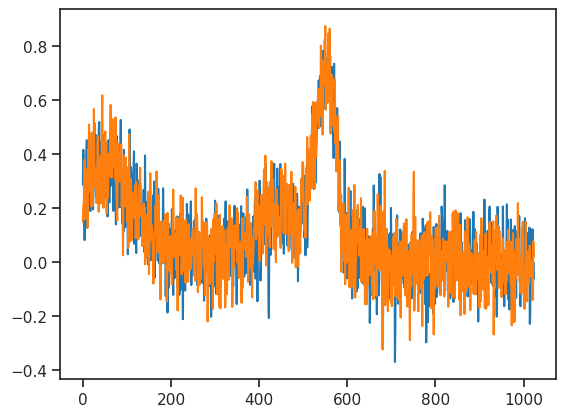

In [ ]:
eps=100
plt.plot( (torch.linalg.pinv(torch.eye(KK.shape[0])+eps*KK))@((C_test.squeeze(1)[6]+0.1*torch.randn_like(C_test.squeeze(1)[6]))+eps*K_T@G_test.squeeze(1)[6]) )
plt.plot(torch.linalg.lstsq( torch.eye(KK.shape[0])+eps*KK ,( (C_test.squeeze(1)[6]+0.1*torch.randn_like(C_test.squeeze(1)[6]))+eps*K_T@G_test.squeeze(1)[6] ) )[0].numpy() )